In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

base = '/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory'
conditions = ['wiii8', 'anosmic', '9047', '23129', '33300']
condition_colors = {
    'wiii8': '#385491',
    'anosmic': '#be0f0a',
    '9047': '#e7533a',
    '23129': '#fc8c59',
    '33300': '#fead61',
}

bouts = pd.concat(
    [pd.read_csv(f'{base}/{c}/interaction_type_bout.csv').assign(condition=c) for c in conditions],
    ignore_index=True,
)

distance = pd.concat(
    [pd.read_csv(f'{base}/{c}/distance_travelled.csv').assign(condition=c) for c in conditions],
    ignore_index=True,
)

In [2]:
# Each bout counts once for both larvae involved.
long = pd.concat([
    bouts[['condition', 'file', 'track_1']].rename(columns={'track_1': 'track'}),
    bouts[['condition', 'file', 'track_2']].rename(columns={'track_2': 'track'}),
])

n_bouts = long.groupby(['condition', 'file', 'track']).size().reset_index(name='n_bouts')

In [3]:
# Total distance travelled by each larva.
per_larva = distance.groupby(['condition', 'file', 'track'], as_index=False)['distance_travelled'].max()

# Keep every tracked larva, including the ones that never interacted.
per_larva = per_larva.merge(n_bouts, on=['condition', 'file', 'track'], how='left')
per_larva['n_bouts'] = per_larva['n_bouts'].fillna(0)

print(per_larva.groupby('condition').size().rename('n_larvae'))

condition
23129      51
33300      50
9047       50
anosmic    50
wiii8      50
Name: n_larvae, dtype: int64


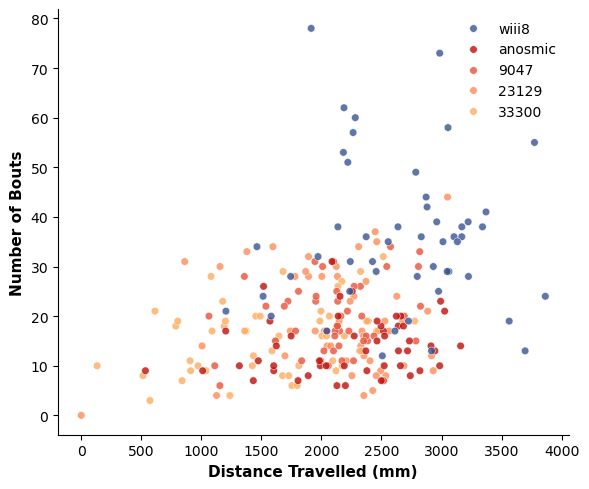

In [4]:
plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=per_larva,
    x='distance_travelled',
    y='n_bouts',
    hue='condition',
    hue_order=conditions,
    palette=condition_colors,
    s=30,
    alpha=0.8,
)

plt.xlabel('Distance Travelled (mm)', fontsize=11, fontweight='bold')
plt.ylabel('Number of Bouts', fontsize=11, fontweight='bold')
plt.legend(frameon=False, title=None)
sns.despine()
plt.tight_layout()
plt.show()

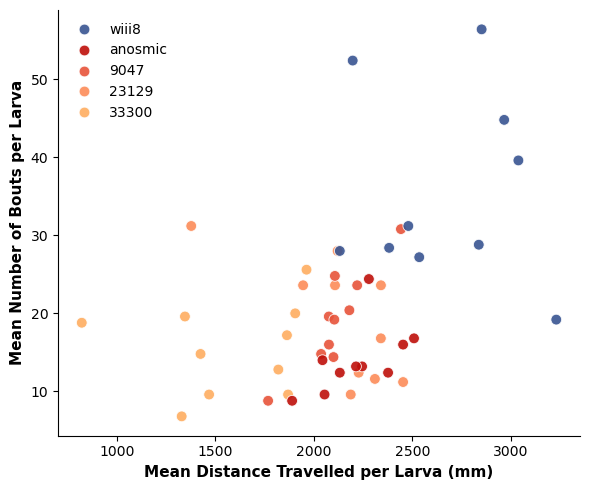

In [5]:
# One point per recording (n = 10 per genotype).
per_recording = per_larva.groupby(['condition', 'file'], as_index=False)[['distance_travelled', 'n_bouts']].mean()

plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=per_recording,
    x='distance_travelled',
    y='n_bouts',
    hue='condition',
    hue_order=conditions,
    palette=condition_colors,
    s=60,
    alpha=0.9,
)

plt.xlabel('Mean Distance Travelled per Larva (mm)', fontsize=11, fontweight='bold')
plt.ylabel('Mean Number of Bouts per Larva', fontsize=11, fontweight='bold')
plt.legend(frameon=False, title=None)
sns.despine()
plt.tight_layout()
plt.show()